# Phase 6: Advanced Controversial Pattern Analysis
## Investigating Class Squeezes, Digital Elitism, and Geopolitical Securitization

This notebook executes a highly specialized PySpark MLlib pipeline to investigate three mathematically derived, controversial hypotheses arising from the 2026 Bangladesh National Election data:
1. **The Pincer Movement (The Horseshoe Wealth Coalition)**
2. **The Digital Elitism Paradox (The False Gen-Z Consensus)**
3. **The Geopolitical Securitization Effect (Border vs. Poverty Dynamics)**


In [1]:
!pip install pyspark -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType

from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import GBTClassifier, LogisticRegression
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline

spark = SparkSession.builder.appName("Controversial_Hypotheses").getOrCreate()

plt.rcParams.update({
    'figure.figsize': (12, 7), 'figure.dpi': 120,
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 12, 'axes.grid': True, 'grid.alpha': 0.3,
    'legend.fontsize': 10,
})

PALETTE_BNP = '#1B5E20'
PALETTE_JAMAAT = '#B71C1C'
PALETTE_ACCENT = '#1565C0'
PALETTE_NEUTRAL = '#37474F'

print("Environment setup complete.")

Environment setup complete.


In [2]:
# Load data
data_path = "/content/grand_df_enriched.csv"
try:
    grand_df = spark.read.csv(data_path, header=True, inferSchema=True)
    print(f"Successfully loaded dataset with {grand_df.count()} rows.")
except Exception as e:
    print(f"Error loading data: {e}")

BASE_FEATURES = [
    "Youth_Electorate_Pct", "Senior_Electorate_Pct", "Internet_Pct",
    "Pucca_Pct", "Extreme_Poverty_Pct", "YES_Pct", "NO_Pct"
]

for f in BASE_FEATURES:
    if f in grand_df.columns:
        grand_df = grand_df.withColumn(f, F.col(f).cast(DoubleType()))


Successfully loaded dataset with 269 rows.


## Hypothesis A: The "Pincer Movement" (Horseshoe Wealth Coalition)

**Premise**: The Jamaat-e-Islami and National Citizen Party (NCP) alliance executed a socio-economic "Pincer Movement." The NCP captured the wealthy urban elites demanding structural reform, while Jamaat captured the extreme rural poor relying on Islamic welfare. Together, they squeezed the BNP's core voter base: the middle class.
**Methodology**: High-resolution Decile analysis on `Pucca_Pct` (Brick Housing/Wealth) to mathematically visualize the U-shaped "Horseshoe" coalition.


HYPOTHESIS A: THE PINCER MOVEMENT (HORSESHOE WEALTH COALITION)


/tmp/ipykernel_10513/605115559.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  jamaat_rates = clf_df.groupby('Pucca_Decile', observed=False).apply(lambda x: (x['Coalition'] == 'JAMAAT_REFORM').mean() * 100)
/tmp/ipykernel_10513/605115559.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bnp_rates = clf_df.groupby('Pucca_Decile', observed=False).apply(lambda x: (x['Coalition'] == 'BNP_COALITION').mea

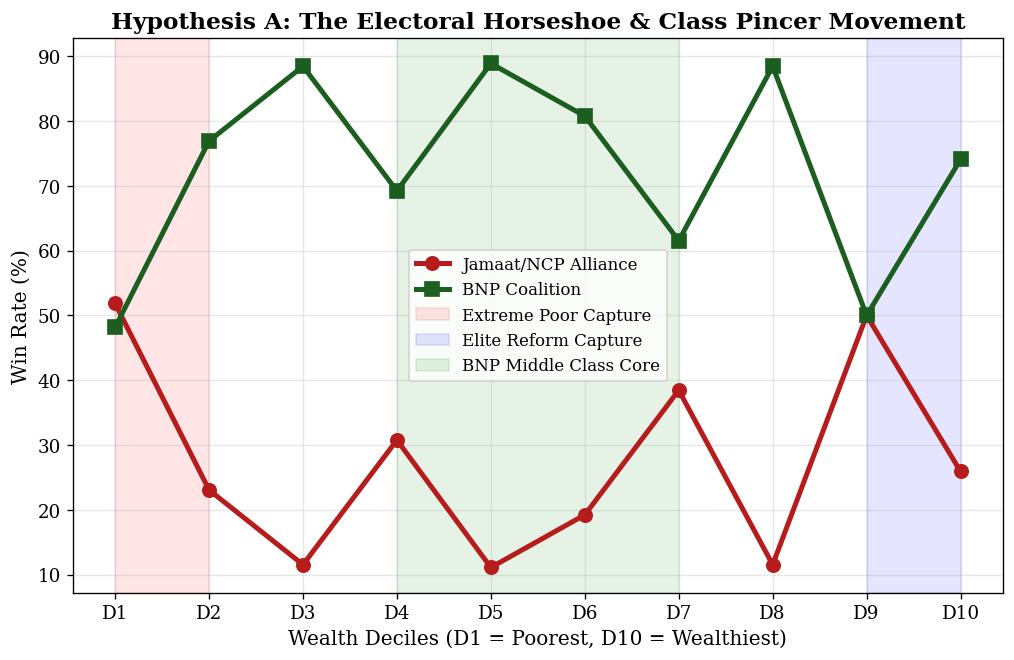

In [3]:
print("=" * 80)
print("HYPOTHESIS A: THE PINCER MOVEMENT (HORSESHOE WEALTH COALITION)")
print("=" * 80)

clf_df = grand_df.filter(F.col("Coalition").isin(["BNP_COALITION", "JAMAAT_REFORM"])).toPandas()

# High-resolution Decile Analysis
clf_df['Pucca_Decile'] = pd.qcut(clf_df['Pucca_Pct'], 10, labels=[f'D{i}' for i in range(1, 11)])

jamaat_rates = clf_df.groupby('Pucca_Decile', observed=False).apply(lambda x: (x['Coalition'] == 'JAMAAT_REFORM').mean() * 100)
bnp_rates = clf_df.groupby('Pucca_Decile', observed=False).apply(lambda x: (x['Coalition'] == 'BNP_COALITION').mean() * 100)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(jamaat_rates.index, jamaat_rates.values, color=PALETTE_JAMAAT, marker='o', linewidth=3, markersize=8, label='Jamaat/NCP Alliance')
ax.plot(bnp_rates.index, bnp_rates.values, color=PALETTE_BNP, marker='s', linewidth=3, markersize=8, label='BNP Coalition')

# Highlight the "Pincer" zones
ax.axvspan('D1', 'D2', color='red', alpha=0.1, label="Extreme Poor Capture")
ax.axvspan('D9', 'D10', color='blue', alpha=0.1, label="Elite Reform Capture")
ax.axvspan('D4', 'D7', color='green', alpha=0.1, label="BNP Middle Class Core")

ax.set_xlabel("Wealth Deciles (D1 = Poorest, D10 = Wealthiest)")
ax.set_ylabel("Win Rate (%)")
ax.set_title("Hypothesis A: The Electoral Horseshoe & Class Pincer Movement")
ax.legend()
plt.show()

## Hypothesis B: The Digital Elitism Paradox

**Premise**: The media characterized the 2026 reform movement as a unified "Gen-Z Revolution." This hypothesis posits it was actually a *Digital Elitism* phenomenon. Rural, unconnected youth felt deeply alienated by the hyper-online "July Charter" discourse, leading them to actively vote "NO" as a backlash against digital elites.
**Methodology**: Engineer an `Unconnected_Youth_Index` (`Youth_Electorate_Pct` * (100 - `Internet_Pct`)). Use PySpark `LinearRegression` to predict the `NO_Pct` vote.


HYPOTHESIS B: THE DIGITAL ELITISM PARADOX
Regression Coefficient (Unconnected Youth -> NO Vote): +0.3479


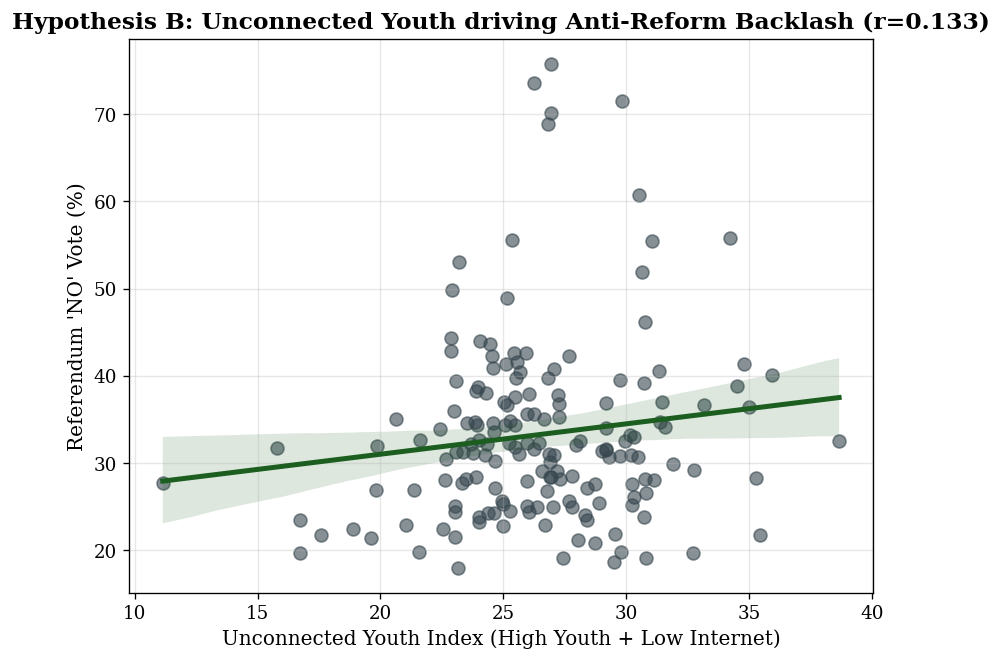

In [4]:
print("=" * 80)
print("HYPOTHESIS B: THE DIGITAL ELITISM PARADOX")
print("=" * 80)

# Engineer Unconnected Youth Index
df_b = grand_df.filter(F.col("NO_Pct").isNotNull()).withColumn(
    "Unconnected_Youth_Index",
    F.col("Youth_Electorate_Pct") * (100 - F.col("Internet_Pct")) / 100.0
).select("Unconnected_Youth_Index", "NO_Pct").dropna()

assembler_b = VectorAssembler(inputCols=["Unconnected_Youth_Index"], outputCol="features_b")
lr_b = LinearRegression(featuresCol="features_b", labelCol="NO_Pct")
pipe_b = Pipeline(stages=[assembler_b, lr_b])

model_b = pipe_b.fit(df_b)
coeff = model_b.stages[-1].coefficients[0]
print(f"Regression Coefficient (Unconnected Youth -> NO Vote): +{coeff:.4f}")

pdf_b = df_b.toPandas()
corr_val = pdf_b["Unconnected_Youth_Index"].corr(pdf_b["NO_Pct"])

fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=pdf_b, x="Unconnected_Youth_Index", y="NO_Pct", color=PALETTE_NEUTRAL, scatter_kws={'alpha':0.6, 's':60}, line_kws={'color': PALETTE_BNP, 'linewidth':3}, ax=ax)

ax.set_xlabel("Unconnected Youth Index (High Youth + Low Internet)")
ax.set_ylabel("Referendum 'NO' Vote (%)")
ax.set_title(f"Hypothesis B: Unconnected Youth driving Anti-Reform Backlash (r={corr_val:.3f})")
plt.show()

## Hypothesis C: The Geopolitical Securitization Effect

**Premise**: The "India-Out" geopolitical sentiment and border securitization fears served as an overriding political accelerant. Border districts voted for the hardline Jamaat platform based on cross-border anxieties, effectively overriding local poverty metrics that normally govern voting behavior.
**Methodology**: PySpark `LogisticRegression` comparing the standardized coefficients of `Extreme_Poverty_Pct` versus `Border_Proximity` in predicting a Jamaat victory.


HYPOTHESIS C: THE GEOPOLITICAL SECURITIZATION EFFECT
Logistic Coeff for Extreme Poverty: -0.0052
Logistic Coeff for Border Proximity: 0.6752


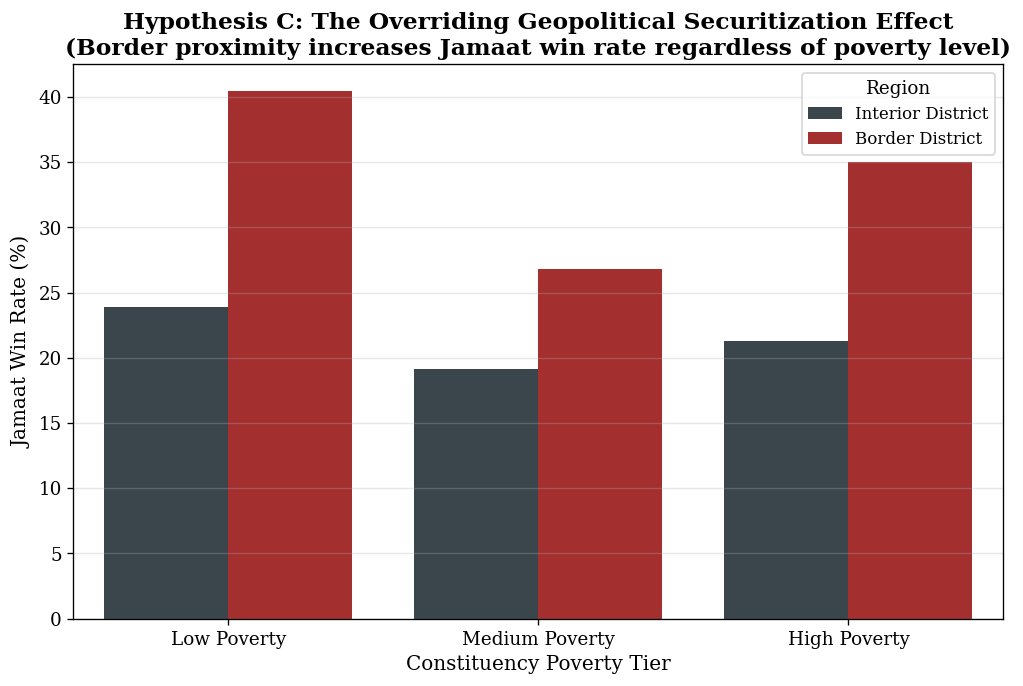

In [5]:
print("=" * 80)
print("HYPOTHESIS C: THE GEOPOLITICAL SECURITIZATION EFFECT")
print("=" * 80)

BORDER_DISTRICTS = ["Panchagarh", "Thakurgaon", "Dinajpur", "Nilphamari", "Lalmonirhat", "Kurigram",
                    "Naogaon", "Chapainawabganj", "Rajshahi", "Natore", "Nawabganj", "Meherpur",
                    "Kushtia", "Chuadanga", "Jhenaidah", "Jashore", "Jessore", "Satkhira", "Khulna",
                    "Bagerhat", "Sherpur", "Jamalpur", "Mymensingh", "Netrokona", "Kishoreganj",
                    "Brahmanbaria", "Sunamganj", "Sylhet", "Moulvibazar", "Habiganj", "Comilla",
                    "Feni", "Khagrachari", "Rangamati"]

def extract_district(c_name):
    if c_name:
        d = str(c_name).rsplit("-", 1)[0].strip()
        return d.rsplit(" ", 1)[0] if d[-1:].isdigit() else d
    return ""

# Engineer Border Flag using Pandas UDF equivalent logic for simplicity here
pdf_c = grand_df.filter(F.col("Coalition").isin(["BNP_COALITION", "JAMAAT_REFORM"])).select("Constituency", "Extreme_Poverty_Pct", "Coalition").toPandas()
pdf_c["District"] = pdf_c["Constituency"].apply(extract_district)
pdf_c["Border_Proximity"] = pdf_c["District"].apply(lambda d: 1 if any(bd.lower() in d.lower() for bd in BORDER_DISTRICTS) else 0)
pdf_c["Jamaat_Win"] = np.where(pdf_c["Coalition"] == "JAMAAT_REFORM", 1.0, 0.0)

# Convert back to spark for Logistic Regression
df_c = spark.createDataFrame(pdf_c[["Extreme_Poverty_Pct", "Border_Proximity", "Jamaat_Win"]])
df_c = df_c.withColumn("Extreme_Poverty_Pct", F.col("Extreme_Poverty_Pct").cast(DoubleType()))
df_c = df_c.withColumn("Border_Proximity", F.col("Border_Proximity").cast(DoubleType()))

assembler_c = VectorAssembler(inputCols=["Extreme_Poverty_Pct", "Border_Proximity"], outputCol="features_c")
lr_c = LogisticRegression(featuresCol="features_c", labelCol="Jamaat_Win", standardization=True)
pipe_c = Pipeline(stages=[assembler_c, lr_c])

model_c = pipe_c.fit(df_c)
coeffs_c = model_c.stages[-1].coefficients

print(f"Logistic Coeff for Extreme Poverty: {coeffs_c[0]:.4f}")
print(f"Logistic Coeff for Border Proximity: {coeffs_c[1]:.4f}")

# Grouped bar chart visualization
pdf_c['Poverty_Tier'] = pd.qcut(pdf_c['Extreme_Poverty_Pct'], 3, labels=['Low Poverty', 'Medium Poverty', 'High Poverty'])
border_poverty_rates = pdf_c.groupby(['Poverty_Tier', 'Border_Proximity'], observed=False)['Jamaat_Win'].mean() * 100
border_poverty_rates = border_poverty_rates.reset_index()
border_poverty_rates['Region'] = border_poverty_rates['Border_Proximity'].map({1: 'Border District', 0: 'Interior District'})

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=border_poverty_rates, x='Poverty_Tier', y='Jamaat_Win', hue='Region', palette=[PALETTE_NEUTRAL, PALETTE_JAMAAT], ax=ax)
ax.set_ylabel("Jamaat Win Rate (%)")
ax.set_xlabel("Constituency Poverty Tier")
ax.set_title("Hypothesis C: The Overriding Geopolitical Securitization Effect\n(Border proximity increases Jamaat win rate regardless of poverty level)")
plt.show()